# EfficientNet-B4 Baseline — Shared-Hyperparameter Experiment

**EEEM068 Applied Machine Learning — Individual LSA Coursework**

This notebook retrains the EfficientNet-B4 baseline using the leakage-free
patient-grouped split created in `01_data_preparation.ipynb`.

The experiment uses the shared training configuration that will also be applied
to DeiT III-B/16 and MaxViT-Tiny for a controlled architecture comparison.

Experiment:
- P0 basic preprocessing
- WeightedRandomSampler
- Focal loss with gamma = 2
- Two-phase transfer learning
- Validation QWK checkpoint selection
- Random seed 42

### Why a shared-hyperparameter baseline

The point of this notebook is not to find the best possible EfficientNet-B4 configuration —
it is to fix one training recipe (preprocessing, sampler, loss, schedule, seed) and hold it
constant across three architectures. If EfficientNet-B4, DeiT III-B/16 and MaxViT-Tiny are
all trained with the same recipe, any difference in validation/internal-test performance can
be attributed to the *architecture* rather than to incidental differences in how each model
happened to be tuned.

This notebook trains **exactly one experiment**: `RUN_ID = "exp01_shared_p0_wrs_focal_seed42"`.
No hyperparameter sweep, no architecture comparison, and no test-time augmentation are
included here — those are out of scope for this baseline and are handled separately once all
three architectures have been trained under the same conditions.

### What "good" looks like for this notebook

Before the long training run is started, this notebook should be reviewed **unexecuted**:

- Every cell should be self-explanatory from its markdown alone.
- Section 4 should be run first (cheap) to confirm the split CSVs load correctly and the
  patient-leakage assertions pass, *before* any GPU time is spent.
- Sections 5–12 build and validate the training pipeline (preprocessing, dataset, model,
  loss, metric functions, config save, smoke test) but do not themselves train anything, so
  they can also be sanity-checked cheaply.
- Only Sections 13 and 15 (Phase 1 / Phase 2 training loops) are expensive to run.

### Project deliverables covered by this notebook

The project specification expects a dataset loader, transformations, augmentation, model
design, training, metric monitoring and evaluation visualisations — all of which are covered
end-to-end in Sections 5 through 20 below.

## 1. Imports

Standard scientific-Python stack, plus:
- `cv2` for the P0 preprocessing functions (border cropping, resizing)
- `timm` to instantiate the pretrained EfficientNet-B4 backbone
- `torch.utils.data.WeightedRandomSampler` for minority-class oversampling
- the extended `sklearn.metrics` set (`balanced_accuracy_score`, `precision_score`,
  `recall_score`, `f1_score`, `cohen_kappa_score`, `confusion_matrix`,
  `classification_report`) needed for the fuller metric suite computed after every epoch,
  not just accuracy or loss.

In [2]:
import json
import random
from pathlib import Path

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)

from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

print("Imports OK.")

Imports OK.


## 2. Configuration and output paths

Everything that defines this experiment lives in this one cell: paths, the model/run
identifiers, the class list, image and augmentation settings, and every training
hyperparameter (learning rates, batch size, epoch budgets, weight decay, dropout, focal-loss
gamma, early-stopping patience, gradient clipping).

Keeping all of this in a single cell, rather than scattered across the notebook, is what
lets `config.json` (Section 11) be a faithful, complete record of exactly what was run —
and what lets the *same* cell be copied unchanged into the DeiT III and MaxViT notebooks,
with only `MODEL_NAME` and `RUN_ID` differing.

Outputs are organised per-model, per-run, so re-running this notebook with a different
`RUN_ID` never overwrites a previous experiment's logs, checkpoints or figures.

In [3]:
PROJECT_ROOT = Path(
    "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"
)

SPLITS_DIR = PROJECT_ROOT / "configs" / "splits"

TRAIN_CSV = SPLITS_DIR / "train_split.csv"
VAL_CSV = SPLITS_DIR / "val_split.csv"
TEST_CSV = SPLITS_DIR / "internal_test_split.csv"

MODEL_NAME = "efficientnet_b4"
RUN_ID = "exp01_shared_p0_wrs_focal_seed42"

RUN_LOG_DIR = PROJECT_ROOT / "logs" / MODEL_NAME / RUN_ID
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / MODEL_NAME / RUN_ID
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / MODEL_NAME / RUN_ID
PREDICTION_DIR = PROJECT_ROOT / "results" / "predictions"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"

for directory in [
    RUN_LOG_DIR,
    CHECKPOINT_DIR,
    FIGURE_DIR,
    PREDICTION_DIR,
    TABLE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

SEED = 42

NUM_CLASSES = 5
CLASS_NAMES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR",
]

PREPROCESSING = "P0"

IMAGE_SIZE = 224
IMGNET_MEAN = (0.485, 0.456, 0.406)
IMGNET_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 16

PHASE1_EPOCHS = 10
PHASE2_EPOCHS = 25

PHASE1_HEAD_LR = 3e-4
PHASE2_HEAD_LR = 1e-4
PHASE2_BACK_LR = 1e-5

WEIGHT_DECAY = 1e-2
DROPOUT = 0.3
NUM_WORKERS = 4
EARLY_STOPPING_PATIENCE = 8
GRAD_CLIP = 1.0

FOCAL_GAMMA = 2.0

PHASE1_BEST_PATH = CHECKPOINT_DIR / "phase1_best.pt"
FINAL_BEST_PATH = CHECKPOINT_DIR / "best_model.pt"

print(f"Run          : {MODEL_NAME}/{RUN_ID}")
print(f"Logs         -> {RUN_LOG_DIR}")
print(f"Checkpoints  -> {CHECKPOINT_DIR}")
print(f"Figures      -> {FIGURE_DIR}")

Run          : efficientnet_b4/exp01_shared_p0_wrs_focal_seed42
Logs         -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42
Checkpoints  -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/checkpoints/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42
Figures      -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42


## 3. Reproducibility and device

`set_seed()` fixes every source of randomness this notebook touches (Python, NumPy, PyTorch,
CUDA), and also forces cuDNN into its deterministic mode. `seed_worker()` is passed to every
`DataLoader` so that the per-worker RNG used for augmentation is likewise reproducible across
runs, rather than depending on however PyTorch happens to seed worker processes by default.

Together with the fixed `RUN_ID` and the checkpoint/log paths from Section 2, this means the
whole pipeline — from data loading through to final metrics — is intended to be
re-run-reproducible, not just "seeded in spirit".

This cell also **fails hard if no CUDA GPU is available**. EfficientNet-B4 with 224px
batches is not something this notebook should silently start training on CPU — a mis-set
runtime would otherwise waste hours before anyone noticed.

In [4]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

if device.type != "cuda":
    raise RuntimeError(
        "CUDA GPU is not available. Do not start this training run on CPU."
    )

Device: cuda
GPU: NVIDIA RTX A4000


## 4. Load and validate the patient-grouped splits

This loads the three manifests produced by `01_data_preparation.ipynb` and re-validates them
independently, rather than trusting them blindly:

- all three manifests contain the required columns,
- every referenced image file actually exists on disk,
- the three partitions together account for all 35,126 labelled images, and
- no `patient_id` appears in more than one partition.

Running this section is cheap and does not touch the GPU, so it is worth executing on its
own before committing to a full training run — if the data-preparation outputs have moved,
been regenerated, or drifted in any way, this cell will fail loudly here rather than
surfacing as a confusing error deep inside training.

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

required_columns = {
    "image",
    "level",
    "patient_id",
    "eye",
    "filepath",
}

for split_name, frame in [
    ("train", train_df),
    ("validation", val_df),
    ("internal test", test_df),
]:
    missing_columns = required_columns - set(frame.columns)

    if missing_columns:
        raise ValueError(
            f"{split_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    missing_files = frame.loc[
        ~frame["filepath"].map(
            lambda path: Path(path).exists()
        )
    ]

    if len(missing_files) > 0:
        raise FileNotFoundError(
            f"{split_name} contains "
            f"{len(missing_files):,} missing image files."
        )

assert len(train_df) + len(val_df) + len(test_df) == 35_126

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print(f"Train         : {len(train_df):,}")
print(f"Validation    : {len(val_df):,}")
print(f"Internal test : {len(test_df):,}")
print("Patient leakage check: PASSED")

Train         : 24,586
Validation    : 5,270
Internal test : 5,270
Patient leakage check: PASSED


## 5. P0 preprocessing

This baseline uses **only P0** — the conservative preprocessing variant defined in
`01_data_preparation.ipynb`: load as RGB, crop the uninformative black border, pad onto a
centred square canvas, then resize. It deliberately excludes Ben Graham local-contrast
enhancement and any legacy P2 variant, so that any performance difference observed later
between architectures is not confounded by which preprocessing variant each one happened to
use.

`PREPROCESSING = "P0"` is recorded in the run configuration (Section 2) precisely so this
choice is explicit and auditable, rather than implicit in which function happens to be
called.

In [6]:
P0_SIZE = IMAGE_SIZE


def _load_rgb(path: str) -> np.ndarray:
    """Load an image file and return it as an RGB uint8 array."""
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Cannot decode image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def _crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    """Crop the uninformative black padding around the retinal disc."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y + h, x:x + w]


def _pad_square(img: np.ndarray) -> np.ndarray:
    """Pad an image onto a centred square canvas (no resizing yet)."""
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = img
    return canvas


def preprocess_p0(image_path: str, output_size: int = P0_SIZE) -> np.ndarray:
    """P0: crop black borders, pad to square, resize."""
    img = _load_rgb(image_path)
    img = _crop_black_borders(img)
    img = _pad_square(img)
    return cv2.resize(
        img,
        (output_size, output_size),
        interpolation=cv2.INTER_AREA,
    )


print(f"P0 preprocessing ready. Output size: {P0_SIZE}x{P0_SIZE}, RGB, uint8.")

P0 preprocessing ready. Output size: 224x224, RGB, uint8.


## 6. Dataset and transformations

`DRDataset` reads the image path directly from the manifest's `filepath` column rather than
reconstructing a path from a processed-image directory — there is no separate
`train_proc` / `val_proc` folder in this pipeline, since P0 is applied on the fly from the
original archive images.

It also returns the row's `index` alongside the image and label. This is what lets every
test-set prediction be matched back to its exact `image` / `patient_id` / `eye` later in
Section 19, without relying on loader order being preserved (which it is not, once a
sampler or multiple workers are involved).

Augmentation is applied only to the training set. The validation and internal-test sets use
a lighter, deterministic `eval_transform` (resize + centre-crop, no random augmentation),
since evaluation is expected to be repeatable given a fixed model checkpoint.

In [7]:
class DRDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        transform=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]

        image = preprocess_p0(row["filepath"])
        image = Image.fromarray(image)

        label = int(row["level"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label, index

In [8]:
train_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    transforms.RandomApply(
        [transforms.RandomRotation(degrees=30)],
        p=0.5,
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05,
            )
        ],
        p=0.4,
    ),

    transforms.RandomApply(
        [
            transforms.RandomAffine(
                degrees=0,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05),
            )
        ],
        p=0.3,
    ),

    transforms.ToTensor(),
    transforms.Normalize(IMGNET_MEAN, IMGNET_STD),
    transforms.RandomErasing(p=0.2),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.05)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMGNET_MEAN, IMGNET_STD),
])

train_ds = DRDataset(
    train_df,
    transform=train_transform,
)

val_ds = DRDataset(
    val_df,
    transform=eval_transform,
)

test_ds = DRDataset(
    test_df,
    transform=eval_transform,
)

print(f"train_ds: {len(train_ds):,} | val_ds: {len(val_ds):,} | test_ds: {len(test_ds):,}")

train_ds: 24,586 | val_ds: 5,270 | test_ds: 5,270


## 7. WeightedRandomSampler and DataLoaders

`WeightedRandomSampler` (WRS) is used for this shared experiment so that every training
epoch draws roughly equally from all five grades, rather than mostly from the dominant
"No DR" class. Per-sample weights are the inverse of each sample's class frequency in
`train_df`, and the sampler is given its own seeded `torch.Generator` so the sampling order
is reproducible run to run.

Validation and internal-test loaders use `shuffle=False` — there is no sampler-induced
class rebalancing at evaluation time, since evaluation should reflect the natural class
distribution of each partition, not an artificially rebalanced one.

In [9]:
class_counts = (
    train_df["level"]
    .value_counts()
    .sort_index()
)

class_weights = (
    1.0 / class_counts.values.astype(float)
)

sample_weights = torch.tensor(
    [
        class_weights[label]
        for label in train_df["level"].values
    ],
    dtype=torch.double,
)

sampler_generator = torch.Generator()
sampler_generator.manual_seed(SEED)

wrs = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=sampler_generator,
)

print("Class counts (train):", class_counts.to_dict())
print(
    "Class weights (WRS) :",
    {CLASS_NAMES[i]: f"{w:.4f}" for i, w in enumerate(class_weights)},
)

Class counts (train): {0: 18062, 1: 1709, 2: 3698, 3: 610, 4: 507}
Class weights (WRS) : {'No DR': '0.0001', 'Mild': '0.0006', 'Moderate': '0.0003', 'Severe': '0.0016', 'Proliferative DR': '0.0020'}


In [10]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=wrs,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

print(
    f"Train batches: {len(train_loader)} | "
    f"Val batches: {len(val_loader)} | "
    f"Test batches: {len(test_loader)}"
)

Train batches: 1536 | Val batches: 330 | Test batches: 330


## 8. EfficientNet-B4 model

EfficientNet-B4 pretrained on ImageNet-1K, with a custom five-class head.
The exact parameter count is calculated directly from the instantiated model.

The backbone's own classifier is removed (`num_classes=0`, `global_pool='avg'`), and a small
custom head — `LayerNorm -> Dropout -> Linear` — is attached to map the pooled feature vector
onto the five DR grades. Parameter counts are always computed from the live model object
rather than hard-coded, so this figure stays correct even if `timm`'s implementation changes.

In [11]:
def build_efficientnet_model(pretrained: bool = True) -> nn.Module:
    """Build EfficientNet-B4 with a custom 5-class classification head."""
    backbone = timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=0,
        global_pool="avg",
    )
    feat_dim = backbone.num_features

    backbone.custom_head = nn.Sequential(
        nn.LayerNorm(feat_dim),
        nn.Dropout(p=DROPOUT),
        nn.Linear(feat_dim, NUM_CLASSES),
    )

    _base_forward = backbone.forward
    backbone.forward = lambda x: backbone.custom_head(_base_forward(x))

    return backbone


model = build_efficientnet_model(pretrained=True).to(device)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_parameters:,}")

Model: efficientnet_b4
Total parameters: 17,561,165


## 9. Focal loss and two-phase optimisation setup

**FocalLoss(alpha=None, gamma=2)** down-weights easy, already-confident examples and focuses
gradient signal on hard ones. `alpha=None` means uniform class priors — the loss itself does
not add extra class weighting, since the WeightedRandomSampler is already responsible for
class balance at the sampling stage. Combining both a class-weighted loss *and* WRS would
double up the rebalancing effect, so this experiment applies exactly one of the two.

Training is **two-phase**:

- **Phase 1** freezes the backbone and trains only `custom_head`, so the randomly
  initialised head can adapt to the pretrained features without large, destabilising
  gradients flowing back into EfficientNet's pretrained weights.
- **Phase 2** unfreezes every parameter and fine-tunes the whole network, using a lower
  learning rate for the backbone than for the head (`PHASE2_BACK_LR` <
  `PHASE2_HEAD_LR`), since the backbone is already well-initialised and only needs gentle
  adaptation, while the head still benefits from a somewhat larger step size.

Both phases use `AdamW` with `CosineAnnealingLR`, mixed-precision training (`torch.autocast`
+ `GradScaler`) for speed, and gradient-norm clipping for stability.

In [12]:
class FocalLoss(nn.Module):
    """Focal Loss for multi-class classification.
    alpha=None -> uniform class priors (WRS already balances sampling).
    gamma=2 is the standard down-weighting exponent for easy examples.
    """
    def __init__(self, alpha=None, gamma: float = FOCAL_GAMMA, reduction: str = "mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean() if self.reduction == "mean" else loss.sum()


criterion = FocalLoss(alpha=None, gamma=FOCAL_GAMMA)
print("Loss:", criterion)


def freeze_backbone(model: nn.Module) -> None:
    """Freeze all parameters except the custom_head."""
    for name, param in model.named_parameters():
        param.requires_grad = ("custom_head" in name)


def unfreeze_all(model: nn.Module) -> None:
    """Unfreeze all parameters."""
    for param in model.parameters():
        param.requires_grad = True


freeze_backbone(model)
trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1 trainable params: {trainable_p1:,} (head only, backbone frozen)")

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS
)

Loss: FocalLoss()
Phase 1 trainable params: 12,549 (head only, backbone frozen)


## 10. Metric and epoch functions

`run_epoch()` performs a single training or evaluation pass and returns a full metrics
dictionary — **loss, accuracy, balanced accuracy, macro-F1 and quadratic-weighted kappa
(QWK)**, plus the raw per-sample **labels, predictions, class probabilities and dataset
indices**.

Reporting more than one metric matters here: accuracy alone is a poor guide on an imbalanced
five-class problem like this one, so balanced accuracy and macro-F1 are tracked so that
minority-class performance can't silently hide behind a high overall accuracy. QWK is kept as
the primary model-selection metric in Sections 13 and 15 because it is the standard metric for
ordinal grading tasks like diabetic-retinopathy severity, where predicting "Moderate" for a
"Severe" case should be penalised less than predicting "No DR".

Returning `indices` alongside predictions is what makes it possible to reconstruct a
per-image prediction table (Section 19) after training, matching every prediction back to
its `image`, `patient_id` and `eye`.

The loop itself is written defensively: it raises if `train_mode=True` is called without an
optimizer, it wraps the forward pass in `torch.set_grad_enabled(train_mode)` so evaluation
never builds an unnecessary gradient graph (faster and lighter on GPU memory), it guards
against an empty loader, and it raises immediately if QWK comes back `NaN` or infinite —
which can otherwise happen silently if a batch ends up with a degenerate label distribution.

In [13]:
use_amp = device.type == "cuda"

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp,
)


def run_epoch(
    loader,
    optimizer=None,
    train_mode: bool = True,
    grad_clip: float = GRAD_CLIP,
):
    """Run one complete training or evaluation epoch."""

    if train_mode and optimizer is None:
        raise ValueError(
            "An optimizer must be supplied during training."
        )

    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_preds = []
    all_probs = []
    all_indices = []

    description = "train" if train_mode else "eval"

    for images, labels, indices in tqdm(
        loader,
        leave=False,
        desc=description,
    ):
        images = images.to(
            device,
            non_blocking=True,
        )
        labels = labels.to(
            device,
            non_blocking=True,
        )

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        # Gradients are enabled only during training.
        with torch.set_grad_enabled(train_mode):
            with torch.autocast(
                device_type=device.type,
                enabled=use_amp,
            ):
                logits = model(images)
                loss = criterion(logits, labels)

        if train_mode:
            scaler.scale(loss).backward()

            if grad_clip > 0:
                scaler.unscale_(optimizer)

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    grad_clip,
                )

            scaler.step(optimizer)
            scaler.update()

        probabilities = F.softmax(
            logits.detach(),
            dim=1,
        )

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_preds.extend(
            probabilities.argmax(dim=1).cpu().tolist()
        )
        all_labels.extend(
            labels.detach().cpu().tolist()
        )
        all_probs.extend(
            probabilities.cpu().tolist()
        )
        all_indices.extend(
            indices.cpu().tolist()
        )

    if total_samples == 0:
        raise RuntimeError(
            "The DataLoader produced no samples."
        )

    epoch_qwk = cohen_kappa_score(
        all_labels,
        all_preds,
        weights="quadratic",
    )

    if not np.isfinite(epoch_qwk):
        raise RuntimeError(
            "QWK became NaN or infinity during the epoch."
        )

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(
            all_labels,
            all_preds,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            all_labels,
            all_preds,
        ),
        "macro_f1": f1_score(
            all_labels,
            all_preds,
            average="macro",
            zero_division=0,
        ),
        "qwk": epoch_qwk,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "indices": all_indices,
    }

## 11. Save experiment configuration

Before training starts, the full configuration is written to
`logs/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42/config.json`. This is a plain,
human-readable record of every setting used for this run — model name, run ID, seed,
preprocessing variant, image size, batch size, per-phase epoch budgets and learning rates,
weight decay, dropout, focal-loss gamma, early-stopping patience and gradient-clip value —
so the experiment can be reproduced or audited later without having to re-read the whole
notebook.

It also captures the *environment* the run happened in — GPU name, PyTorch and `timm`
versions, worker count and mixed-precision flag — plus the exact split CSV paths and the
augmentation and normalisation parameters actually used. None of this changes between epochs,
but all of it can silently change between machines or environments, which is exactly the kind
of detail that's easy to lose track of and hard to reconstruct after the fact.

In [14]:
experiment_config = {
    "model_name": MODEL_NAME,
    "run_id": RUN_ID,
    "seed": SEED,
    "preprocessing": PREPROCESSING,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "phase1_epochs": PHASE1_EPOCHS,
    "phase2_epochs": PHASE2_EPOCHS,
    "phase1_head_lr": PHASE1_HEAD_LR,
    "phase2_head_lr": PHASE2_HEAD_LR,
    "phase2_backbone_lr": PHASE2_BACK_LR,
    "weight_decay": WEIGHT_DECAY,
    "dropout": DROPOUT,
    "focal_gamma": FOCAL_GAMMA,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "grad_clip": GRAD_CLIP,
    "sampler": "WeightedRandomSampler",
    "loss": "FocalLoss(alpha=None)",
    "checkpoint_selection_metric": "validation_qwk",
    "total_parameters": total_parameters,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "internal_test_size": len(test_df),
    "num_workers": NUM_WORKERS,
    "mixed_precision": use_amp,
    "device": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "train_csv": str(TRAIN_CSV),
    "val_csv": str(VAL_CSV),
    "internal_test_csv": str(TEST_CSV),
    "imagenet_mean": list(IMGNET_MEAN),
    "imagenet_std": list(IMGNET_STD),
    "train_augmentation": {
        "resize_factor": 1.14,
        "random_crop": IMAGE_SIZE,
        "horizontal_flip_probability": 0.5,
        "vertical_flip_probability": 0.5,
        "rotation_degrees": 30,
        "random_erasing_probability": 0.2,
    },
}

config_path = RUN_LOG_DIR / "config.json"
with open(config_path, "w") as f:
    json.dump(experiment_config, f, indent=2)

print(f"Saved -> {config_path}")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42/config.json


## 12. Pipeline smoke test

A quick, cheap check that the model and data pipeline actually fit together before spending
any real GPU time on Phase 1: pull a single batch and confirm the model produces the
expected `(batch, NUM_CLASSES)` output shape from it.

This deliberately uses `val_loader`, not `train_loader`. Pulling a batch from `train_loader`
here would consume one draw from the seeded `WeightedRandomSampler` before training actually
starts, which would make the very first training batch different from what a from-scratch
run would otherwise produce. `val_loader` has no sampler, so drawing a batch from it here has
no effect on anything that follows.

The model is explicitly switched to `eval()` for this forward pass and restored to its
previous mode afterwards. Running a forward pass in `train()` mode here would update
EfficientNet's BatchNorm running statistics using this one throwaway batch before Phase 1
has even started — a subtle side effect that would otherwise go unnoticed. The check also
confirms the output contains no `NaN`/`inf` values and that every sampled label falls inside
the valid `[0, NUM_CLASSES)` range, catching a corrupt batch or a labelling bug before any
real training time is spent.

In [15]:
sample_images, sample_labels, sample_indices = next(
    iter(val_loader)
)

previous_training_mode = model.training
model.eval()

with torch.inference_mode():
    with torch.autocast(
        device_type=device.type,
        enabled=use_amp,
    ):
        sample_outputs = model(
            sample_images[:2].to(
                device,
                non_blocking=True,
            )
        )

model.train(previous_training_mode)

assert sample_outputs.shape == (2, NUM_CLASSES), (
    f"Unexpected model output shape: "
    f"{sample_outputs.shape}"
)

assert torch.isfinite(sample_outputs).all(), (
    "The model output contains NaN or infinity."
)

assert sample_labels.min() >= 0
assert sample_labels.max() < NUM_CLASSES

print("Input batch shape   :", sample_images.shape)
print("Output shape        :", sample_outputs.shape)
print("Sample label range  :", (
    int(sample_labels.min()),
    int(sample_labels.max()),
))
print("Pipeline smoke test : PASSED")

Input batch shape   : torch.Size([16, 3, 224, 224])
Output shape        : torch.Size([2, 5])
Sample label range  : (0, 0)
Pipeline smoke test : PASSED


## 13. Phase 1 training — head only, backbone frozen

Every epoch is appended to `history` as soon as it completes, and the running history is
re-saved to `training_history.csv` after every epoch rather than only at the very end. If
training is interrupted for any reason (crash, timeout, manual stop), the log up to that
point is not lost.

The checkpoint at `PHASE1_BEST_PATH` is updated whenever validation QWK improves *during
Phase 1 only*. This checkpoint is not the final model — it exists purely so Phase 2 can
resume fine-tuning from the best head-only state rather than from whatever the head looked
like after the very last Phase 1 epoch (which, under early stopping, is not necessarily the
best one).

Each `epoch_record` also stores the learning rate actually used that epoch
(`learning_rate_head`, and `learning_rate_backbone` — fixed at 0.0 in Phase 1, since the
backbone isn't being trained yet). Recording this directly in `training_history.csv`, rather
than only in `config.json`, makes it possible to see the cosine schedule's effect on the loss
and QWK curves after the fact, without having to recompute it separately.

`FINAL_BEST_PATH` is also tracked across both phases using a single running best QWK, since
in principle a Phase-1 checkpoint could — before backbone fine-tuning even starts — already
be a reasonable model.

In [15]:
history = []
global_epoch = 0
best_val_qwk = -1.0
phase1_best_qwk = -1.0

print("=" * 60)
print("  PHASE 1 -- Head only (backbone frozen)")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8}")
print("-" * 52)

patience_left = EARLY_STOPPING_PATIENCE

for phase_epoch in range(1, PHASE1_EPOCHS + 1):
    global_epoch += 1
    current_head_lr = optimizer_p1.param_groups[0]["lr"]

    train_metrics = run_epoch(train_loader, optimizer=optimizer_p1, train_mode=True)
    val_metrics = run_epoch(val_loader, train_mode=False)
    scheduler_p1.step()

    epoch_record = {
        "global_epoch": global_epoch,
        "phase": 1,
        "phase_epoch": phase_epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate_backbone": 0.0,
        "learning_rate_head": current_head_lr,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(
        RUN_LOG_DIR / "training_history.csv", index=False
    )

    marker = ""
    if val_metrics["qwk"] > phase1_best_qwk:
        phase1_best_qwk = val_metrics["qwk"]
        torch.save(
            {
                "epoch": global_epoch,
                "phase": 1,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            PHASE1_BEST_PATH,
        )
        marker += "  [phase1 best]"

    if val_metrics["qwk"] > best_val_qwk:
        best_val_qwk = val_metrics["qwk"]
        patience_left = EARLY_STOPPING_PATIENCE
        torch.save(
            {
                "epoch": global_epoch,
                "phase": 1,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            FINAL_BEST_PATH,
        )
        marker += "  [overall best]"
    else:
        patience_left -= 1

    print(
        f"{phase_epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f}{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping (Phase 1) at epoch {phase_epoch}.")
        break

print(f"\nPhase 1 best val QWK = {phase1_best_qwk:.4f}")

  PHASE 1 -- Head only (backbone frozen)
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK
----------------------------------------------------


train:   0%|          | 0/1536 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

1            0.8858   0.4926     0.7124   0.3004  [phase1 best]  [overall best]


train:   0%|          | 0/1536 [00:00<?, ?it/s]

...

eval:   0%|          | 0/330 [00:00<?, ?it/s]

9            0.7505   0.5716        nan   0.3527  [phase1 best]  [overall best]


train:   0%|          | 0/1536 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

10           0.7475   0.5704     0.6499   0.3505

Phase 1 best val QWK = 0.3527


## 14. Reload best Phase 1 checkpoint before fine-tuning

The previous version of this experiment moved straight from the last Phase 1 epoch into
Phase 2, without reloading the best Phase 1 checkpoint first — meaning that, under early
stopping, Phase 2 could start from a slightly *worse* head than the one actually saved as
"best". Reloading `PHASE1_BEST_PATH` here corrects that: Phase 2 always begins from the
best head-only state observed, which makes the two-phase process more rigorous and its
results easier to attribute to the fine-tuning stage itself.

In [16]:
phase1_checkpoint = torch.load(
    PHASE1_BEST_PATH,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(
    phase1_checkpoint["model_state"]
)

print(
    "Reloaded best Phase 1 checkpoint from "
    f"epoch {phase1_checkpoint['epoch']} "
    f"(val QWK={phase1_checkpoint['val_qwk']:.4f})."
)

unfreeze_all(model)
trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 trainable params: {trainable_p2:,} (all layers unfrozen)")

Reloaded best Phase 1 checkpoint from epoch 9 (val QWK=0.3527).
Phase 2 trainable params: 17,561,165 (all layers unfrozen)


## 15. Phase 2 training — full fine-tune

The backbone and head now use different learning rates (`PHASE2_BACK_LR` <
`PHASE2_HEAD_LR`), reflecting that the backbone is already well pretrained and needs only
gentle adjustment, while the head — trained from scratch in Phase 1 — can still tolerate a
larger step size. Checkpoint selection continues to use **validation QWK only**, following
directly on from `best_val_qwk` carried over from Phase 1, so the single `FINAL_BEST_PATH`
checkpoint reflects the best epoch across *either* phase.

The internal test set is not touched anywhere in this section — model selection is based
purely on the validation partition, and the internal test set is reserved entirely for the
one-off evaluation in Section 17, after all training and validation-based selection is
complete.

In [17]:
backbone_params = [p for n, p in model.named_parameters() if "custom_head" not in n]
head_params = [p for n, p in model.named_parameters() if "custom_head" in n]

optimizer_p2 = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": PHASE2_BACK_LR},
        {"params": head_params, "lr": PHASE2_HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS
)

print("=" * 60)
print("  PHASE 2 -- All layers unfrozen")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8}")
print("-" * 52)

patience_left = EARLY_STOPPING_PATIENCE

for phase_epoch in range(1, PHASE2_EPOCHS + 1):
    global_epoch += 1
    current_backbone_lr = optimizer_p2.param_groups[0]["lr"]
    current_head_lr = optimizer_p2.param_groups[1]["lr"]

    train_metrics = run_epoch(train_loader, optimizer=optimizer_p2, train_mode=True)
    val_metrics = run_epoch(val_loader, train_mode=False)
    scheduler_p2.step()

    epoch_record = {
        "global_epoch": global_epoch,
        "phase": 2,
        "phase_epoch": phase_epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate_backbone": current_backbone_lr,
        "learning_rate_head": current_head_lr,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(
        RUN_LOG_DIR / "training_history.csv", index=False
    )

    marker = ""
    if val_metrics["qwk"] > best_val_qwk:
        best_val_qwk = val_metrics["qwk"]
        patience_left = EARLY_STOPPING_PATIENCE
        torch.save(
            {
                "epoch": global_epoch,
                "phase": 2,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            FINAL_BEST_PATH,
        )
        marker = "  [overall best]"
    else:
        patience_left -= 1

    print(
        f"{phase_epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f}{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping (Phase 2) at epoch {phase_epoch}.")
        break

print(f"\nBest val QWK = {best_val_qwk:.4f} -> {FINAL_BEST_PATH.name}")

  PHASE 2 -- All layers unfrozen
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK
----------------------------------------------------


train:   0%|          | 0/1536 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

1            0.7296   0.5903     0.6872   0.3360


train:   0%|          | 0/1536 [00:00<?, ?it/s]

...

eval:   0%|          | 0/330 [00:00<?, ?it/s]

24           0.5114   0.7507     0.4909   0.5174


train:   0%|          | 0/1536 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

25           0.5130   0.7494        nan   0.4806

Best val QWK = 0.5209 -> best_model.pt


## 16. Training curves

Loss and QWK are plotted for both train and validation across every epoch actually run, with
a vertical marker at the Phase 1 -> Phase 2 transition. This makes it easy to see, at a
glance, whether fine-tuning the full backbone in Phase 2 produced a clear improvement over
the head-only Phase 1 plateau, or whether most of the gain (or overfitting) happened in one
phase specifically.

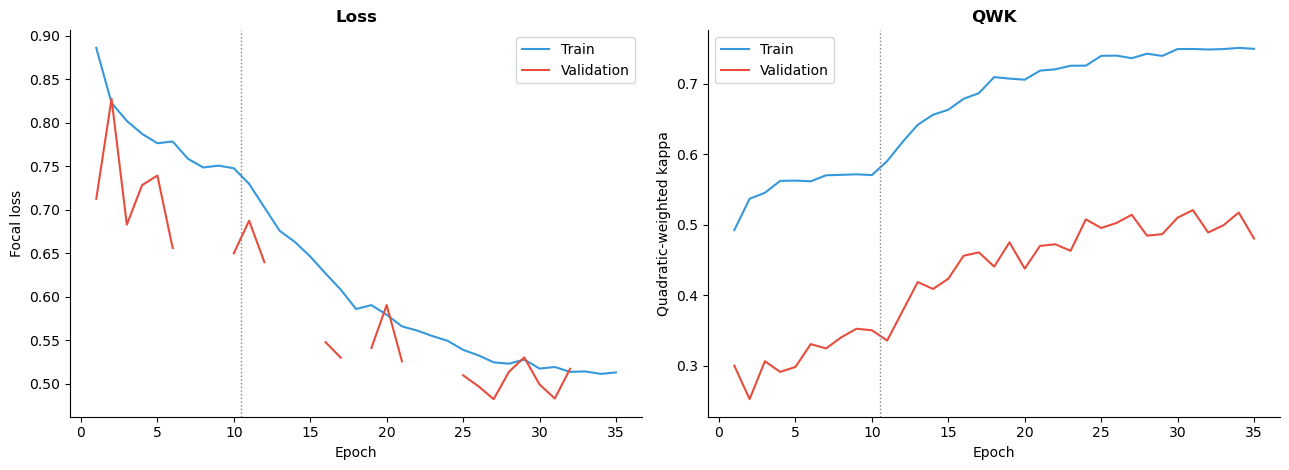

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42/training_curves.png


In [18]:
history_df = pd.DataFrame(history)
phase_transition_epoch = (
    history_df.loc[history_df["phase"] == 1, "global_epoch"].max()
    if (history_df["phase"] == 1).any() else None
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history_df["global_epoch"], history_df["train_loss"], label="Train", color="#3498DB")
axes[0].plot(history_df["global_epoch"], history_df["val_loss"], label="Validation", color="#E74C3C")
if phase_transition_epoch is not None:
    axes[0].axvline(phase_transition_epoch + 0.5, color="gray", linestyle=":", linewidth=1)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Focal loss")
axes[0].set_title("Loss", fontweight="bold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(history_df["global_epoch"], history_df["train_qwk"], label="Train", color="#3498DB")
axes[1].plot(history_df["global_epoch"], history_df["val_qwk"], label="Validation", color="#E74C3C")
if phase_transition_epoch is not None:
    axes[1].axvline(phase_transition_epoch + 0.5, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Quadratic-weighted kappa")
axes[1].set_title("QWK", fontweight="bold")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'training_curves.png'}")

## 17. Internal-test evaluation

The internal test set is evaluated **exactly once**, here, using the checkpoint saved at
`FINAL_BEST_PATH` — the epoch with the best *validation* QWK across both phases. No
selection or tuning decision is made using internal-test performance; it is used purely to
report a final, held-out estimate of how this configuration generalises.

Alongside QWK, accuracy, balanced accuracy and macro-F1, macro-averaged precision and recall
are reported too, since those two numbers separately show whether errors lean toward
over-calling or under-calling disease across classes — something macro-F1 alone collapses
into a single figure. `zero_division=0` is set on every precision/recall/F1 call so that a
class with zero predicted or zero true samples in a given batch reports a defined `0.0`
rather than raising a warning or `nan`.

In [19]:
model = build_efficientnet_model(pretrained=False).to(device)

final_checkpoint = torch.load(
    FINAL_BEST_PATH,
    map_location=device,
    weights_only=False,
)
model.load_state_dict(final_checkpoint["model_state"])

print(f"Loaded: {FINAL_BEST_PATH.name}")
print(
    f"epoch={final_checkpoint['epoch']}  "
    f"val_qwk={final_checkpoint['val_qwk']:.4f}"
)

test_metrics = run_epoch(test_loader, train_mode=False)

test_macro_precision = precision_score(
    test_metrics["labels"],
    test_metrics["preds"],
    average="macro",
    zero_division=0,
)

test_macro_recall = recall_score(
    test_metrics["labels"],
    test_metrics["preds"],
    average="macro",
    zero_division=0,
)

print()
print("=" * 60)
print(f"  {MODEL_NAME} / {RUN_ID} -- INTERNAL TEST SET RESULTS")
print("=" * 60)
print(f"  Test QWK               : {test_metrics['qwk']:.4f}")
print(f"  Test accuracy           : {test_metrics['accuracy']:.4f}")
print(f"  Test balanced accuracy  : {test_metrics['balanced_accuracy']:.4f}")
print(f"  Test macro F1           : {test_metrics['macro_f1']:.4f}")
print(f"  Test macro precision    : {test_macro_precision:.4f}")
print(f"  Test macro recall       : {test_macro_recall:.4f}")
print()
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    digits=3,
    zero_division=0,
))

Loaded: best_model.pt
epoch=31  val_qwk=0.5209


eval:   0%|          | 0/330 [00:00<?, ?it/s]


  efficientnet_b4 / exp01_shared_p0_wrs_focal_seed42 -- INTERNAL TEST SET RESULTS
  Test QWK               : 0.5179
  Test accuracy           : 0.5689
  Test balanced accuracy  : 0.4788
  Test macro F1           : 0.3978
  Test macro precision    : 0.3801
  Test macro recall       : 0.4788

                  precision    recall  f1-score   support

           No DR      0.859     0.638     0.732      3875
            Mild      0.094     0.309     0.144       366
        Moderate      0.385     0.358     0.371       794
          Severe      0.280     0.544     0.370       136
Proliferative DR      0.281     0.545     0.371        99

        accuracy                          0.569      5270
       macro avg      0.380     0.479     0.398      5270
    weighted avg      0.709     0.569     0.621      5270



In [16]:
# Load the already-trained best Exp01 EfficientNet checkpoint.
# This does not perform training.

model = build_efficientnet_model(
    pretrained=False
).to(device)

final_checkpoint = torch.load(
    FINAL_BEST_PATH,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(
    final_checkpoint["model_state"]
)

model.eval()

print("Loaded checkpoint:", FINAL_BEST_PATH)
print("Epoch:", final_checkpoint["epoch"])
print("Validation QWK:", final_checkpoint["val_qwk"])

Loaded checkpoint: /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/checkpoints/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42/best_model.pt
Epoch: 31
Validation QWK: 0.520873459093179


In [17]:
# ============================================================
# Validation-only export for M13
# ============================================================

all_logits = []
all_labels = []
all_indices = []

model.eval()

with torch.inference_mode():
    for images, labels, indices in tqdm(
        val_loader,
        desc="Exporting validation predictions",
    ):
        images = images.to(
            device,
            non_blocking=True,
        )

        with torch.autocast(
            device_type=device.type,
            enabled=use_amp,
        ):
            logits = model(images)

        all_logits.append(
            logits.float().cpu().numpy()
        )

        all_labels.append(
            labels.numpy()
        )

        all_indices.append(
            indices.numpy()
        )

validation_logits = np.concatenate(
    all_logits,
    axis=0,
)

validation_labels = np.concatenate(
    all_labels,
    axis=0,
)

validation_indices = np.concatenate(
    all_indices,
    axis=0,
)

validation_probabilities = torch.softmax(
    torch.from_numpy(validation_logits),
    dim=1,
).numpy()

validation_predictions = validation_probabilities.argmax(
    axis=1
)

# The dataset indices refer to val_df after reset_index(drop=True).
validation_rows = (
    val_df.reset_index(drop=True)
    .iloc[validation_indices]
    .reset_index(drop=True)
)

validation_image_ids = (
    validation_rows["image"]
    .astype(str)
    .tolist()
)

assert validation_logits.shape == (
    len(val_df),
    NUM_CLASSES,
)

assert np.array_equal(
    validation_labels,
    validation_rows["level"].to_numpy(),
)

np.save(
    RUN_LOG_DIR / "validation_logits.npy",
    validation_logits,
)

np.save(
    RUN_LOG_DIR / "validation_probabilities.npy",
    validation_probabilities,
)

np.save(
    RUN_LOG_DIR / "validation_labels.npy",
    validation_labels,
)

pd.DataFrame({
    "image_id": validation_image_ids,
}).to_csv(
    RUN_LOG_DIR / "validation_image_ids.csv",
    index=False,
)

validation_predictions_df = pd.DataFrame({
    "image_id": validation_image_ids,
    "true_label": validation_labels,
    "predicted_label": validation_predictions,
    "confidence": validation_probabilities.max(axis=1),
})

for grade in range(NUM_CLASSES):
    validation_predictions_df[
        f"logit_grade_{grade}"
    ] = validation_logits[:, grade]

    validation_predictions_df[
        f"prob_grade_{grade}"
    ] = validation_probabilities[:, grade]

validation_predictions_df.to_csv(
    RUN_LOG_DIR / "validation_predictions.csv",
    index=False,
)

print("Validation export complete")
print("Shape:", validation_logits.shape)
print("Saved in:", RUN_LOG_DIR)

Exporting validation predictions:   0%|          | 0/330 [00:00<?, ?it/s]

Validation export complete
Shape: (5270, 5)
Saved in: /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42


## 18. Confusion matrices and per-class metrics

Both raw-count and row-normalised confusion matrices are saved, since the normalised version
is what actually reveals per-class recall on an imbalanced dataset — a rare class can look
fine in the raw-count matrix simply because it has few samples, while the normalised matrix
shows what fraction of *that class's* images were correctly graded.

A separate per-class precision/recall/F1 bar chart is saved alongside the confusion matrices
so that class-level performance can be inspected directly, rather than only through the
single macro-averaged numbers reported in Section 17.

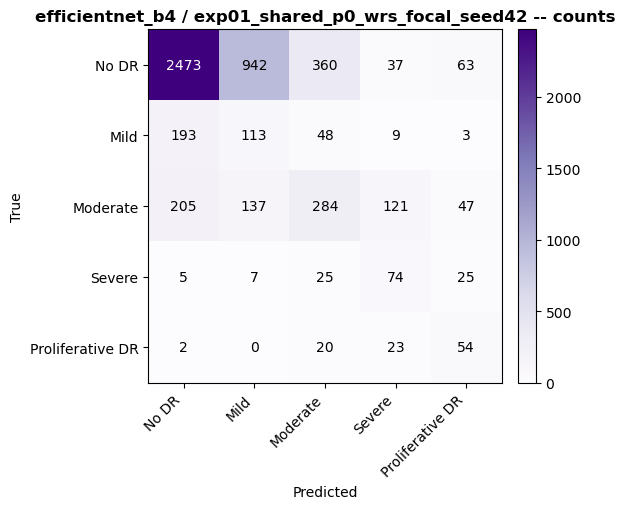

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42/confusion_matrix_counts.png


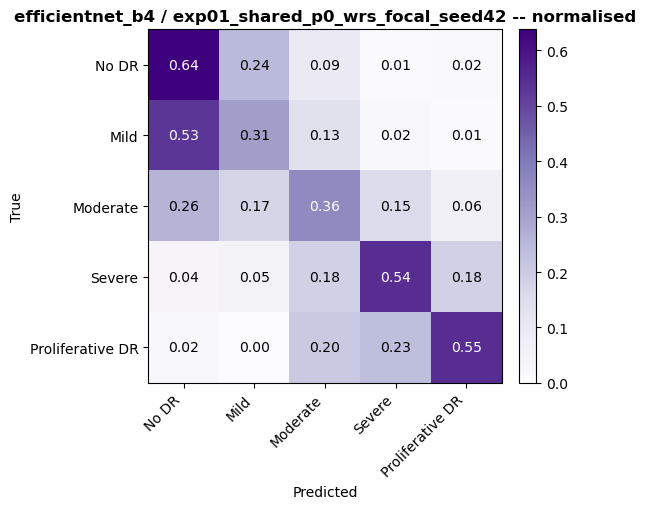

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42/confusion_matrix_normalised.png


In [ ]:
cm_counts = confusion_matrix(test_metrics["labels"], test_metrics["preds"])
cm_normalised = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

for data, title, fmt, filename in [
    (cm_counts, f"{MODEL_NAME} / {RUN_ID} -- counts", "d", "confusion_matrix_counts.png"),
    (cm_normalised, f"{MODEL_NAME} / {RUN_ID} -- normalised", ".2f", "confusion_matrix_normalised.png"),
]:
    fig, ax = plt.subplots(figsize=(6, 5.2))
    im = ax.imshow(data, interpolation="nearest", cmap="Purples")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")

    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i, format(data[i, j], fmt),
                ha="center", va="center",
                color="white" if data[i, j] > thresh else "black",
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {FIGURE_DIR / filename}")

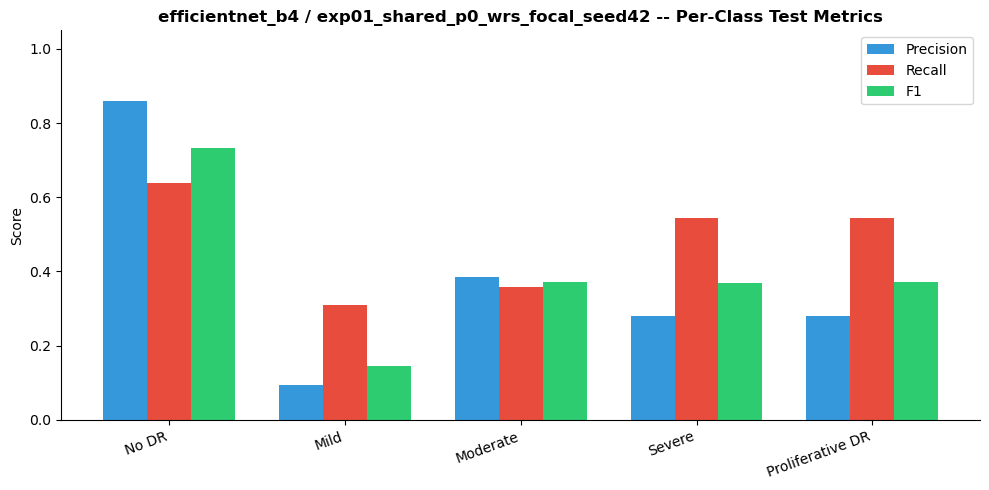

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42/per_class_metrics.png


In [ ]:
per_class_precision = precision_score(
    test_metrics["labels"], test_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_recall = recall_score(
    test_metrics["labels"], test_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_f1 = f1_score(
    test_metrics["labels"], test_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CLASSES)
w = 0.25

ax.bar(x - w, per_class_precision, w, label="Precision", color="#3498DB")
ax.bar(x, per_class_recall, w, label="Recall", color="#E74C3C")
ax.bar(x + w, per_class_f1, w, label="F1", color="#2ECC71")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title(f"{MODEL_NAME} / {RUN_ID} -- Per-Class Test Metrics", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "per_class_metrics.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'per_class_metrics.png'}")

## 19. Save predictions and metrics

Three artefacts are produced here:

- **`best_metrics.json`** — the validation metrics recorded at the epoch that produced
  `FINAL_BEST_PATH`, i.e. the metrics the checkpoint was actually selected on.
- **`test_metrics.json`** — the one-off internal-test metrics computed in Section 17.
- **`efficientnet_b4_exp01_internal_test_predictions.csv`** — a per-image prediction table,
  matching every test prediction back to its `image`, `patient_id` and `eye` using the
  `indices` returned from `run_epoch()`, together with the predicted class probabilities and
  whether the prediction was correct.

`training_history.csv` itself was already written incrementally after every epoch in
Sections 13 and 15, so it does not need to be re-saved here.

In [ ]:
best_metrics = {
    "epoch": final_checkpoint["epoch"],
    "phase": final_checkpoint["phase"],
    "val_loss": final_checkpoint["val_loss"],
    "val_accuracy": final_checkpoint["val_accuracy"],
    "val_balanced_accuracy": final_checkpoint["val_balanced_accuracy"],
    "val_macro_f1": final_checkpoint["val_macro_f1"],
    "val_qwk": final_checkpoint["val_qwk"],
}
best_metrics_path = RUN_LOG_DIR / "best_metrics.json"
with open(best_metrics_path, "w") as f:
    json.dump(best_metrics, f, indent=2)
print(f"Saved -> {best_metrics_path}")

test_metrics_summary = {
    "loss": test_metrics["loss"],
    "accuracy": test_metrics["accuracy"],
    "balanced_accuracy": test_metrics["balanced_accuracy"],
    "macro_f1": test_metrics["macro_f1"],
    "macro_precision": test_macro_precision,
    "macro_recall": test_macro_recall,
    "qwk": test_metrics["qwk"],
    "per_class_precision": per_class_precision.tolist(),
    "per_class_recall": per_class_recall.tolist(),
    "per_class_f1": per_class_f1.tolist(),
}
test_metrics_path = RUN_LOG_DIR / "test_metrics.json"
with open(test_metrics_path, "w") as f:
    json.dump(test_metrics_summary, f, indent=2)
print(f"Saved -> {test_metrics_path}")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42/best_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/efficientnet_b4/exp01_shared_p0_wrs_focal_seed42/test_metrics.json


In [ ]:
pred_rows = test_df.iloc[test_metrics["indices"]].reset_index(drop=True).copy()
pred_rows["true_label"] = test_metrics["labels"]
pred_rows["predicted_label"] = test_metrics["preds"]

probs_array = np.array(test_metrics["probs"])
for grade in range(NUM_CLASSES):
    pred_rows[f"prob_grade_{grade}"] = probs_array[:, grade]

pred_rows["correct"] = pred_rows["true_label"] == pred_rows["predicted_label"]

prediction_columns = [
    "image",
    "patient_id",
    "eye",
    "true_label",
    "predicted_label",
    "prob_grade_0",
    "prob_grade_1",
    "prob_grade_2",
    "prob_grade_3",
    "prob_grade_4",
    "correct",
]

predictions_path = PREDICTION_DIR / f"{MODEL_NAME}_exp01_internal_test_predictions.csv"
pred_rows[prediction_columns].to_csv(predictions_path, index=False)

print(f"Saved -> {predictions_path}  ({len(pred_rows):,} rows)")
pred_rows[prediction_columns].head()

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/predictions/efficientnet_b4_exp01_internal_test_predictions.csv  (5,270 rows)


,image,patient_id,eye,true_label,predicted_label,prob_grade_0,prob_grade_1,prob_grade_2,prob_grade_3,prob_grade_4,correct
0,10_left,10,left,0,0,0.389404,0.353516,0.220459,0.026993,0.009712,True
1,10_right,10,right,0,2,0.127319,0.089722,0.334961,0.154297,0.293701,False
2,21_left,21,left,0,0,0.434326,0.288818,0.241943,0.027573,0.007442,True
3,21_right,21,right,0,0,0.514160,0.370850,0.108032,0.005432,0.001275,True
4,46_left,46,left,0,1,0.432129,0.496826,0.061768,0.004978,0.004284,False


## 20. Final observations

*To be completed after this notebook has actually been run — this section is intentionally
left as a template while the notebook is reviewed unexecuted.*

Once training has finished, record here:

- **Headline result**: internal-test QWK, accuracy, balanced accuracy and macro-F1, and how
  they compare to what would be expected from a five-class ordinal grading task with this
  degree of class imbalance.
- **Where Phase 2 helped (or didn't)**: whether unfreezing the backbone in Phase 2 produced a
  clear jump in validation QWK over the Phase 1 plateau (see `training_curves.png`), or
  whether most of the gain was already present after Phase 1.
- **Per-class weak points**: which grades had the lowest recall in the normalised confusion
  matrix, and whether that pattern matches expectations for adjacent, easily-confused DR
  grades (e.g. Mild vs Moderate).
- **Anything unusual observed during training**: early stopping triggering earlier or later
  than expected, loss instability, or any other behaviour worth noting before this same
  recipe is applied to DeiT III-B/16 and MaxViT-Tiny.

No cross-model comparison is included in this notebook. That comparison will only be
meaningful once EfficientNet-B4, DeiT III-B/16 and MaxViT-Tiny have all completed training
under this same shared configuration, and will be built as a separate notebook at that
point.